# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 3. 

In [2]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Task 3 - arXiv abstracts

This dataset contains arXiv abstracts over a many year. Let's first load it and examine the fields:

In [3]:
from datasets import load_dataset
from dotenv import load_dotenv
import os


load_dotenv()  # reads from .env file
hf_token = os.getenv("HF_TOKEN")

dataset = load_dataset("gfissore/arxiv-abstracts-2021", split="train", token=hf_token)
print(dataset)

Dataset({
    features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions'],
    num_rows: 1999486
})


We can now filter it to get abstracts about a particular topic or field:

In [10]:
# -----------------------
# Optional: filter by category
# -----------------------
# field1 = "cs.CV" # Example: Machine Learning
field2 = "cs.AI"
def filter_category(example):
    return field1 in example['categories'] #or field2 in example['categories']

filtered = dataset.filter(filter_category)

# -----------------------
# Remove missing/short abstracts
# -----------------------
def valid_abstract(example):
    return example['abstract'] is not None and len(example['abstract']) > 50

filtered = filtered.filter(valid_abstract)

Filter:   0%|          | 0/1999486 [00:00<?, ? examples/s]

Filter:   0%|          | 0/33669 [00:00<?, ? examples/s]

In [37]:
print(filtered)

Dataset({
    features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions'],
    num_rows: 27891
})


In [17]:
import os
from datasets import load_dataset, load_from_disk

save_path = "data/processed/filtered_csLG"

if os.path.exists(save_path):
    filtered = load_from_disk(save_path)
    print(f"Loaded from disk: {len(filtered)} papers")
else:
    dataset = load_dataset("gfissore/arxiv-abstracts-2021", split="train", token=hf_token)
    
    def filter_all(example):
        return (
            'cs.LG' in example['categories'] or 'cs.CL' in example['categories'] or 'cs.AI' in example['categories'] and
            example['abstract'] is not None and
            len(example['abstract']) > 50
        )
    
    filtered = dataset.filter(filter_all, num_proc=8)
    filtered.save_to_disk(save_path)
    print(f"Filtered and saved: {len(filtered)} papers")

Loaded from disk: 27891 papers


Another useful step is to get the date of each abstract, e.g., for plotting trends. This is not stored in the dataset object, but we can infer it from the ID. 

In [18]:
# -----------------------
# Infer year from arXiv ID
# -----------------------
def extract_year(arxiv_id):
    if arxiv_id.startswith("cs/"):
        arxiv_id = arxiv_id.split("/")[1]
    yy = int(arxiv_id[:2])
    return 1900 + yy if yy >= 91 else 2000 + yy

years = [extract_year(x) for x in filtered['id']]

# -----------------------
# Prepare docs
# -----------------------
docs = filtered['abstract']

In [19]:
# Convert to dataframe for easier exploration
df = pd.DataFrame(filtered)

# Basic shape
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(27891, 11)
['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions']
id             object
submitter      object
authors        object
title          object
comments       object
journal-ref    object
doi            object
abstract       object
report-no      object
categories     object
versions       object
dtype: object


In [20]:
df.isnull().sum()

id                 0
submitter        102
authors            0
title              0
comments       10313
journal-ref    24524
doi            25372
abstract           0
report-no      26488
categories         0
versions           0
dtype: int64

In [21]:
# df.duplicated(subset=['id']).sum()        # duplicate paper IDs
df.duplicated(subset=['abstract']).sum()  # exact duplicate abstracts

5

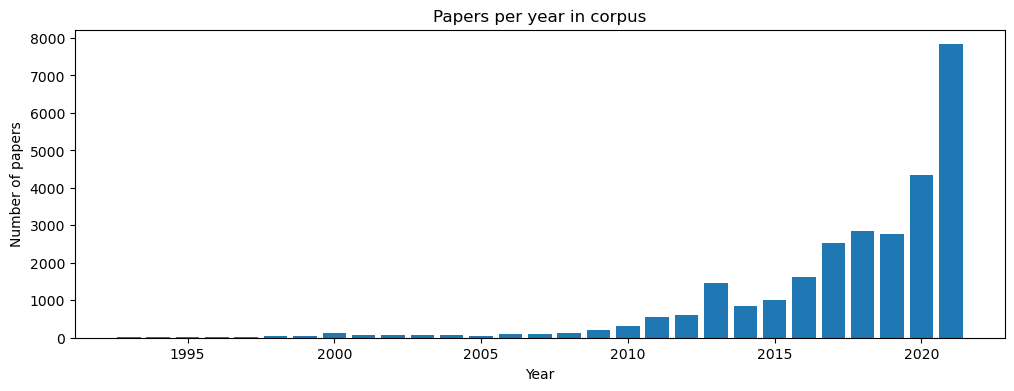

In [22]:
df['year'] = years   # the years list from extract_year()

# Papers per year
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of papers")
plt.title("Papers per year in corpus")
# plt.savefig("outputs/figures/papers_per_year.png")
plt.show()

In [23]:
filtered[0]

{'id': '0704.1274',
 'submitter': 'Dev Rajnarayan',
 'authors': 'David H. Wolpert and Dev G. Rajnarayan',
 'title': 'Parametric Learning and Monte Carlo Optimization',
 'comments': None,
 'journal-ref': None,
 'doi': None,
 'abstract': "  This paper uncovers and explores the close relationship between Monte Carlo\nOptimization of a parametrized integral (MCO), Parametric machine-Learning\n(PL), and `blackbox' or `oracle'-based optimization (BO). We make four\ncontributions. First, we prove that MCO is mathematically identical to a broad\nclass of PL problems. This identity potentially provides a new application\ndomain for all broadly applicable PL techniques: MCO. Second, we introduce\nimmediate sampling, a new version of the Probability Collectives (PC) algorithm\nfor blackbox optimization. Immediate sampling transforms the original BO\nproblem into an MCO problem. Accordingly, by combining these first two\ncontributions, we can apply all PL techniques to BO. In our third contributio

In [24]:
print(df['categories'].apply(type).value_counts())

categories
<class 'list'>    27891
Name: count, dtype: int64


In [25]:
all_cats = [
    cat
    for cats in df['categories'].dropna()
    if isinstance(cats, str)
    for cat in cats.split()
]

In [48]:
# What categories appear alongside your primary filter?
from collections import Counter

all_cats = [cat for cats in df['categories'].str.split() for cat in cats]
cat_counts = Counter(all_cats)
print(pd.Series(cat_counts).sort_values(ascending=False).head(20))

TypeError: 'float' object is not iterable

In [26]:
df['categories'].str

<Axes: title={'center': 'Mean abstract length (words) over time'}, xlabel='year'>

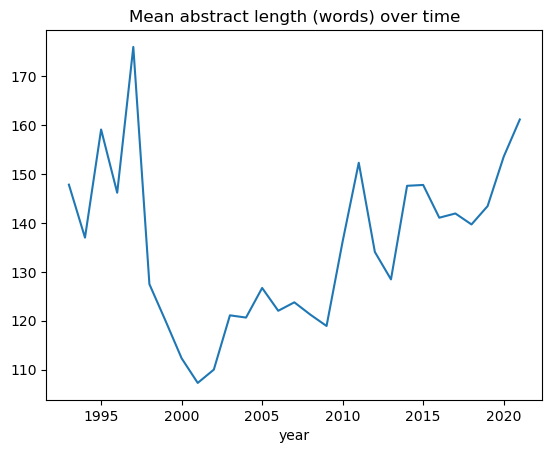

In [27]:
df['abstract_length_chars'] = df['abstract'].str.len()
df['abstract_length_words'] = df['abstract'].str.split().str.len()

# Distribution
df['abstract_length_words'].describe()

# Over time
df.groupby('year')['abstract_length_words'].mean().plot(
    title='Mean abstract length (words) over time'
)
# plt.savefig("outputs/figures/abstract_length_over_time.png")

In [31]:
from collections import Counter
import re

def simple_tokenise(text):
    return re.findall(r'\b[a-z]+\b', text.lower())

all_tokens = [tok for abstract in df['abstract'] for tok in simple_tokenise(abstract)]
vocab = Counter(all_tokens)

print(f"Total tokens: {len(all_tokens)}")
print(f"Unique vocabulary size: {len(vocab)}")
print(f"\nTop 30 most frequent words:")
print(vocab.most_common(30))

Total tokens: 4233879
Unique vocabulary size: 45017

Top 30 most frequent words:
[('the', 229050), ('of', 147461), ('and', 112550), ('to', 107729), ('a', 105063), ('in', 87309), ('we', 68239), ('for', 51939), ('is', 50313), ('that', 48801), ('on', 43911), ('this', 38354), ('with', 32944), ('as', 27181), ('are', 26004), ('by', 24402), ('model', 23396), ('an', 22619), ('our', 22420), ('data', 20558), ('learning', 20117), ('from', 19995), ('which', 18839), ('can', 18325), ('models', 18309), ('based', 17744), ('be', 17196), ('paper', 13609), ('language', 13150), ('it', 13063)]


<Axes: title={'center': 'Unique vocabulary size per year'}>

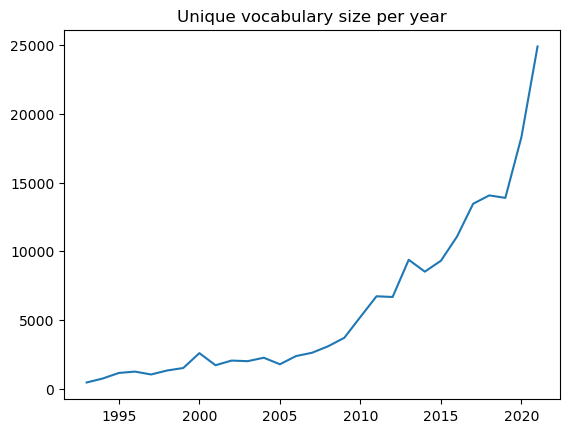

In [29]:
vocab_by_year = {}
for year in sorted(df['year'].unique()):
    year_abstracts = df[df['year'] == year]['abstract']
    tokens = [tok for text in year_abstracts for tok in simple_tokenise(text)]
    vocab_by_year[year] = len(set(tokens))

pd.Series(vocab_by_year).plot(title='Unique vocabulary size per year')
# plt.savefig("outputs/figures/vocab_growth_over_time.png")

In [30]:
# Sample from early period
early = df[df['year'] <= 2005].sample(10)
for _, row in early.iterrows():
    print(row['year'], '|', row['abstract'][:200])
    print('---')

# Sample from recent period
recent = df[df['year'] >= 2018].sample(10)
for _, row in recent.iterrows():
    print(row['year'], '|', row['abstract'][:200])
    print('---')

1994 |   This article describes a new system for induction of oblique decision trees.
This system, OC1, combines deterministic hill-climbing with two forms of
randomization to find a good oblique split (in t
---
2002 |   While recent retrieval techniques do not limit the number of index terms,
out-of-vocabulary (OOV) words are crucial in speech recognition. Aiming at
retrieving information with spoken queries, we fi
---
2000 |   This paper describes a new method, Combi-bootstrap, to exploit existing
taggers and lexical resources for the annotation of corpora with new tagsets.
Combi-bootstrap uses existing resources as featu
---
2005 |   A fuzzy controller is usually designed by formulating the knowledge of a
human expert into a set of linguistic variables and fuzzy rules. Among the most
successful methods to automate the fuzzy cont
---
2005 |   The problem of finding an optimum using noisy evaluations of a smooth cost
function arises in many contexts, including economics, business, med

In [33]:
df_analysis = df[df['year'].between(2010, 2020)]
print(f"Papers in analysis window: {len(df_analysis)}")

Papers in analysis window: 18885


In [34]:
# Use the filtered time window
df_check = df_analysis.copy()

# -------------------------------------------------------
# Thread 1 — Theory vs Application
# -------------------------------------------------------
theory_terms = [
    'theorem', 'proof', 'convergence', 'theoretical',
    'formally', 'lemma', 'complexity', 'bounds'        # added — common in cs.AI/cs.LG theory papers
]
application_terms = [
    'deployment', 'real-world', 'production', 'downstream',
    'practical', 'industry', 'system', 'pipeline',     # added — more common in applied papers
    'benchmark', 'dataset', 'outperforms'              # added — empirical/application framing
]

print("=" * 50)
print("THREAD 1 — Theory vs Application")
print("=" * 50)
print("\nTheory terms:")
for term in theory_terms:
    count = df_check['abstract'].str.contains(term, case=False).sum()
    print(f"  {term}: {count} abstracts ({100*count/len(df_check):.1f}%)")

print("\nApplication terms:")
for term in application_terms:
    count = df_check['abstract'].str.contains(term, case=False).sum()
    print(f"  {term}: {count} abstracts ({100*count/len(df_check):.1f}%)")

# -------------------------------------------------------
# Thread 2 — Limitations Framing
# -------------------------------------------------------
limitation_terms = [
    'limitation', 'drawback', 'however', 'nevertheless', 'future work',
    'weakness', 'constraint', 'restricted to',          # added — explicit limitation language
    'does not', 'cannot', 'fail',                       # added — negative capability framing
    'bias', 'fairness', 'harmful', 'ethical'            # added — emerged as limitations post-2017
]

print("\n" + "=" * 50)
print("THREAD 2 — Limitations Framing")
print("=" * 50)
for term in limitation_terms:
    count = df_check['abstract'].str.contains(term, case=False).sum()
    print(f"  {term}: {count} abstracts ({100*count/len(df_check):.1f}%)")

# -------------------------------------------------------
# Thread 3 — Landmark Terminology
# -------------------------------------------------------
landmark_terms = [
    # Foundational — should appear throughout
    'neural network', 'deep learning',
    # Mid-period wave
    'convolutional', 'recurrent', 'lstm',
    # Transformer era
    'attention', 'transformer', 'bert', 'pre-train',
    # Recent
    'fine-tun', 'large language model', 'prompt'        # 'fine-tun' catches both fine-tune and fine-tuning
]

print("\n" + "=" * 50)
print("THREAD 3 — Landmark Terminology")
print("=" * 50)
for term in landmark_terms:
    count = df_check['abstract'].str.contains(term, case=False).sum()
    print(f"  {term}: {count} abstracts ({100*count/len(df_check):.1f}%)")

# -------------------------------------------------------
# Summary — ratio check
# -------------------------------------------------------
print("\n" + "=" * 50)
print("SUMMARY — Theory vs Application ratio")
print("=" * 50)
theory_count = df_check['abstract'].str.contains(
    '|'.join(theory_terms), case=False
).sum()
application_count = df_check['abstract'].str.contains(
    '|'.join(application_terms), case=False
).sum()

print(f"  Papers with any theory term:       {theory_count} ({100*theory_count/len(df_check):.1f}%)")
print(f"  Papers with any application term:  {application_count} ({100*application_count/len(df_check):.1f}%)")
print(f"  Ratio (application/theory):        {application_count/theory_count:.2f}")

THREAD 1 — Theory vs Application

Theory terms:
  theorem: 155 abstracts (0.8%)
  proof: 216 abstracts (1.1%)
  convergence: 372 abstracts (2.0%)
  theoretical: 805 abstracts (4.3%)
  formally: 114 abstracts (0.6%)
  lemma: 128 abstracts (0.7%)
  complexity: 1025 abstracts (5.4%)
  bounds: 406 abstracts (2.1%)

Application terms:
  deployment: 111 abstracts (0.6%)
  real-world: 856 abstracts (4.5%)
  production: 189 abstracts (1.0%)
  downstream: 408 abstracts (2.2%)
  practical: 729 abstracts (3.9%)
  industry: 148 abstracts (0.8%)
  system: 5220 abstracts (27.6%)
  pipeline: 299 abstracts (1.6%)
  benchmark: 1718 abstracts (9.1%)
  dataset: 4430 abstracts (23.5%)
  outperforms: 1554 abstracts (8.2%)

THREAD 2 — Limitations Framing
  limitation: 478 abstracts (2.5%)
  drawback: 141 abstracts (0.7%)
  however: 3648 abstracts (19.3%)
  nevertheless: 116 abstracts (0.6%)
  future work: 105 abstracts (0.6%)
  weakness: 109 abstracts (0.6%)
  constraint: 1026 abstracts (5.4%)
  restricted 

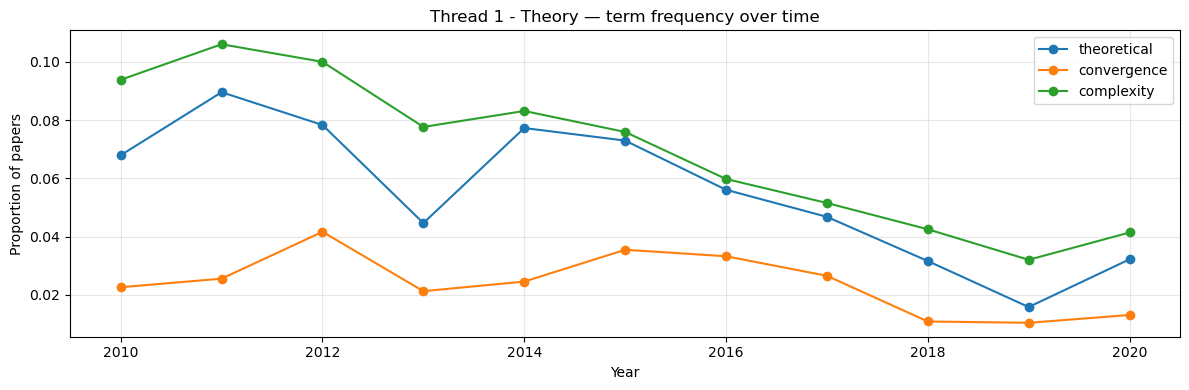

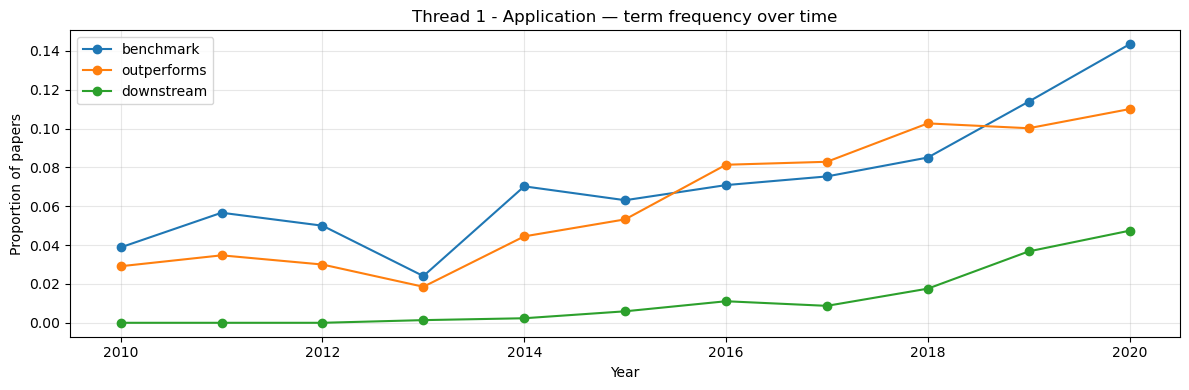

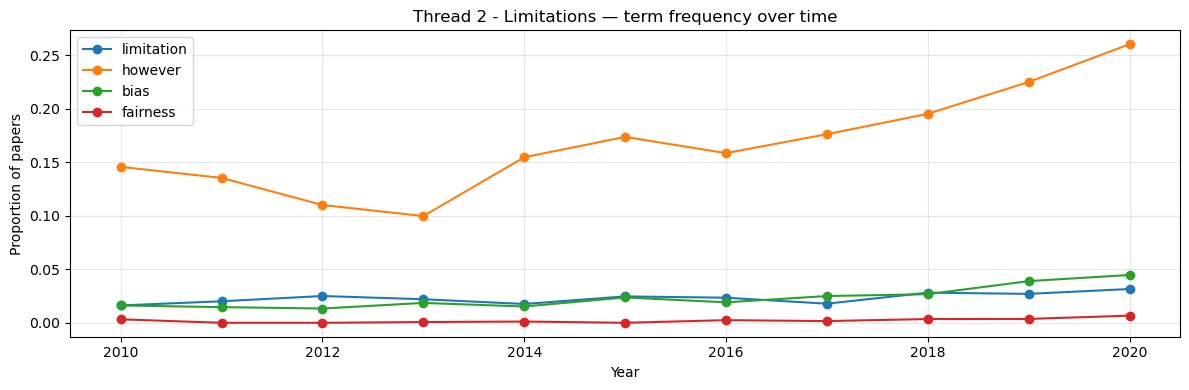

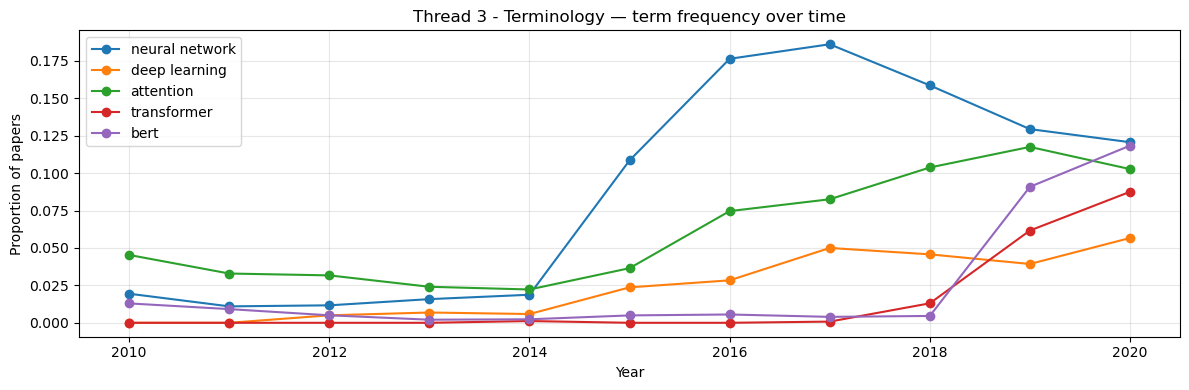

In [35]:
import matplotlib.pyplot as plt

# Pick your most meaningful terms from each thread
terms_to_track = {
    'Thread 1 - Theory': ['theoretical', 'convergence', 'complexity'],
    'Thread 1 - Application': ['benchmark', 'outperforms', 'downstream'],
    'Thread 2 - Limitations': ['limitation', 'however', 'bias', 'fairness'],
    'Thread 3 - Terminology': ['neural network', 'deep learning', 
                                'attention', 'transformer', 'bert']
}

for thread_name, terms in terms_to_track.items():
    fig, ax = plt.subplots(figsize=(12, 4))
    
    for term in terms:
        yearly = df_analysis.groupby('year').apply(
            lambda x: x['abstract'].str.contains(term, case=False).sum() / len(x),
            include_groups=False
        )
        ax.plot(yearly.index, yearly.values, marker='o', label=term)
    
    ax.set_title(f'{thread_name} — term frequency over time')
    ax.set_xlabel('Year')
    ax.set_ylabel('Proportion of papers')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(f"outputs/figures/{thread_name.replace(' ', '_').replace('-','')}_trends.png")
    plt.show()

In [36]:
# Sample abstracts containing a term to check it's being used 
# in the way you intended
term = 'complexity'
samples = df_analysis[df_analysis['abstract'].str.contains(
    term, case=False)]['abstract'].sample(10)

for abstract in samples:
    # Find the sentence containing the term
    sentences = abstract.split('.')
    relevant = [s for s in sentences if term.lower() in s.lower()]
    print(relevant[0] if relevant else abstract[:150])
    print('---')

 One problem often neglected by
current Natural Language Processing systems is the characteristic complexity of
the sentences in biomedical literature
---
 - The number of measurements taken by and the
computational complexity of our algorithm are bounded by a polynomial in both
the number of points k and the dimension d, with no dependence on the
separation \Delta
---
  We study the complexity of the combination of the Description Logics ALCQ and
ALCQI with a terminological formalism based on cardinality restrictions on
concepts
---
 In this
paper, we extend that result by studying the complexity of finding delta-models
for classes of Boolean formulas which are known to have polynomial time
satisfiability solvers
---
 We
further measure the lexical complexity of generated and reference definitions
---
 Although UCBEV in
literature provides a better guarantee, it is important to emphasize that UCBEV
has access to problem complexity (whose computation requires arms' mean and
variances),

## Duplicate & Data Quality Checks

In [61]:
print("=== Data Quality Checks ===")

# Duplicate paper IDs
dup_ids = df_analysis.duplicated(subset=['id']).sum()
print(f"Duplicate IDs: {dup_ids}")

# Duplicate abstracts (same text, different ID)
dup_abstracts = df_analysis.duplicated(subset=['abstract']).sum()
print(f"Duplicate abstracts: {dup_abstracts}")

# Missing values across all columns
print(f"\nMissing values:")
print(df_analysis.isnull().sum())

# Very short abstracts that slipped through
short = df_analysis[df_analysis['abstract'].str.split().str.len() < 20]
print(f"\nAbstracts under 20 words: {len(short)}")
print(short['abstract'].head(3).values)

=== Data Quality Checks ===
Duplicate IDs: 0
Duplicate abstracts: 5

Missing values:
id                           0
submitter                    0
authors                      0
title                        0
comments                  6567
journal-ref              16584
doi                      16901
abstract                     0
report-no                17579
categories                   0
versions                     0
year                         0
abstract_length_chars        0
abstract_length_words        0
dtype: int64

Abstracts under 20 words: 21
['  We derive axiomatically the probability function that should be used to make\ndecisions given any form of underlying uncertainty.\n'
 '  We review the history of the automation of mathematical induction\n'
 '  The chinese room problem asks if computers can think; I ask here if most\nhumans can.\n']


## Abstract Length Distribution

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_4834/2110790521.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['word_count'] = df_analysis['abstract'].str.split().str.len()


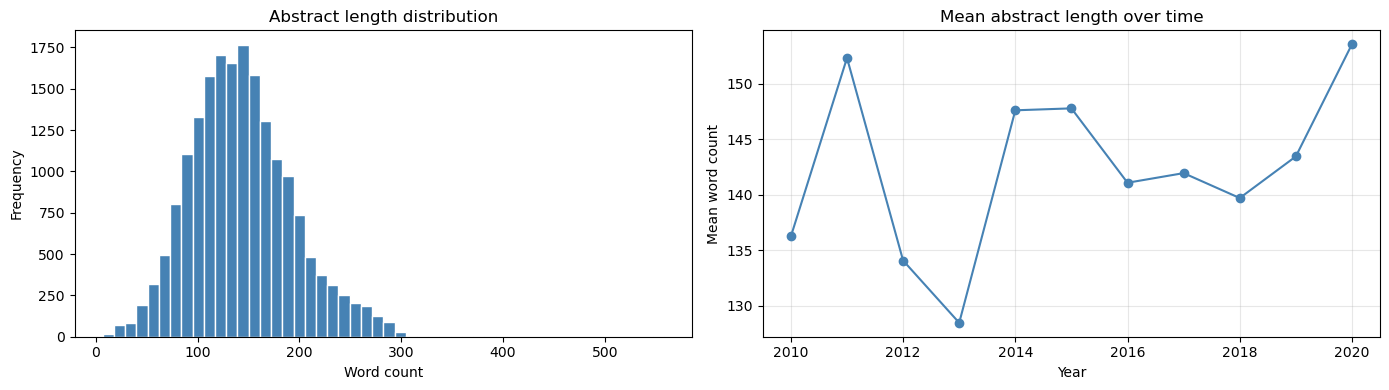

count    18885.000000
mean       143.907652
std         50.849194
min          7.000000
25%        109.000000
50%        140.000000
75%        174.000000
max        558.000000
Name: word_count, dtype: float64


In [63]:
import matplotlib.pyplot as plt
import numpy as np

df_analysis['word_count'] = df_analysis['abstract'].str.split().str.len()

# Overall distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df_analysis['word_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Abstract length distribution')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')

# Mean length over time
length_over_time = df_analysis.groupby('year')['word_count'].mean()
axes[1].plot(length_over_time.index, length_over_time.values, marker='o', color='steelblue')
axes[1].set_title('Mean abstract length over time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean word count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("outputs/figures/abstract_length.png")
plt.show()

print(df_analysis['word_count'].describe())

## Vocabulary Analysis

In [64]:
from collections import Counter
import re

def simple_tokenise(text):
    return re.findall(r'\b[a-z]+\b', text.lower())

# Build vocabulary from entire corpus
all_tokens = [tok for abstract in df_analysis['abstract'] 
              for tok in simple_tokenise(abstract)]
vocab = Counter(all_tokens)

print(f"Total tokens: {len(all_tokens):,}")
print(f"Unique vocabulary: {len(vocab):,}")
print(f"Type-token ratio: {len(vocab)/len(all_tokens):.4f}")

# Top 50 most frequent words
print(f"\nTop 50 most frequent words:")
print(pd.Series(dict(vocab.most_common(50))))

Total tokens: 2,787,261
Unique vocabulary: 36,009
Type-token ratio: 0.0129

Top 50 most frequent words:
the            151689
of              99631
and             73715
a               70644
to              70013
in              58043
we              45406
for             34885
is              33959
that            32699
on              28776
this            25920
with            21592
as              18100
are             17528
by              16222
an              15283
model           15004
our             14667
from            13209
which           12736
data            12166
can             12060
based           11775
learning        11718
be              11681
models          11213
paper            9428
language         9019
it               8926
show             7991
using            7451
results          7426
task             7127
or               7033
approach         6907
such             6891
performance      6768
these            6628
have             6494
problem         

## Build a Domain Stopword List

In [65]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Standard stopwords
standard_stops = set(ENGLISH_STOP_WORDS)

# Domain-specific stopwords — words that are frequent but 
# uninformative for your research questions
domain_stops = {
    'paper', 'propose', 'proposed', 'method', 'approach',
    'show', 'present', 'work', 'model', 'based', 'using',
    'task', 'result', 'performance', 'achieve', 'problem',
    'algorithm', 'data', 'set', 'train', 'test', 'used',
    'learn', 'learning', 'neural', 'network', 'new', 'use'
}

all_stopwords = standard_stops.union(domain_stops)

print(f"Total stopwords: {len(all_stopwords)}")

Total stopwords: 345


## Category Co-occurrence

In [ ]:
# What combination of categories do papers have
def get_relevant_cats(cat_string):
    relevant = []
    for cat in ['cs.LG', 'cs.CL', 'cs.AI']:
        if cat in cat_string:
            relevant.append(cat)
    return '+'.join(sorted(relevant))

df_analysis['cat_combo'] = df_analysis['categories'].apply(get_relevant_cats)

print("Category combinations:")
print(df_analysis['cat_combo'].value_counts())

# Plot it
df_analysis['cat_combo'].value_counts().plot(
    kind='bar', 
    title='Category combinations in corpus',
    figsize=(10, 4)
)
plt.tight_layout()
# plt.savefig("outputs/figures/category_combinations.png")
plt.show()

## Vocabulary Growth Over Time

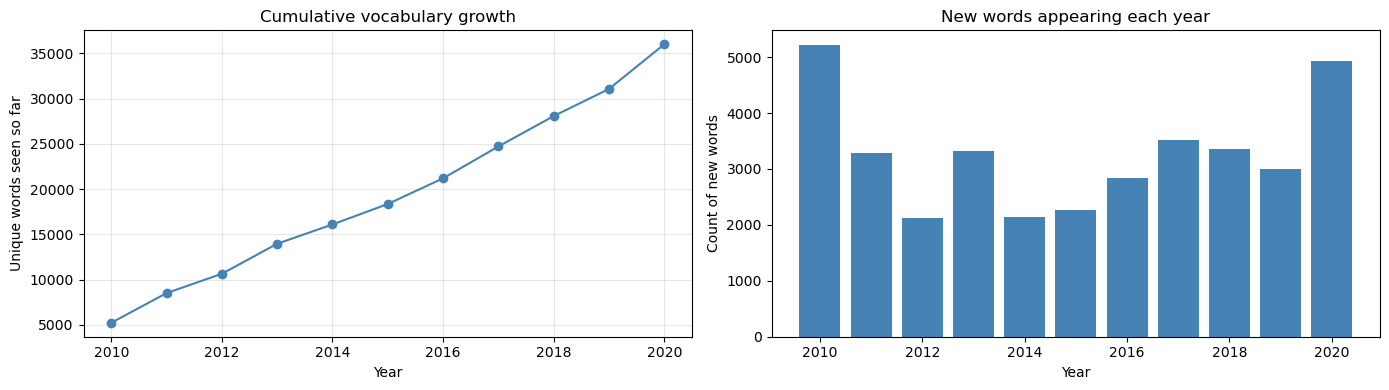

In [68]:
# New words appearing each year
vocab_by_year = {}
seen_vocab = set()
new_words_per_year = {}

for year in sorted(df_analysis['year'].unique()):
    year_abstracts = df_analysis[df_analysis['year'] == year]['abstract']
    year_tokens = set(
        tok for abstract in year_abstracts 
        for tok in simple_tokenise(abstract)
    )
    new_words_per_year[year] = len(year_tokens - seen_vocab)
    seen_vocab.update(year_tokens)
    vocab_by_year[year] = len(seen_vocab)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(vocab_by_year.keys(), vocab_by_year.values(), marker='o', color='steelblue')
axes[0].set_title('Cumulative vocabulary growth')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Unique words seen so far')
axes[0].grid(True, alpha=0.3)

axes[1].bar(new_words_per_year.keys(), new_words_per_year.values(), color='steelblue')
axes[1].set_title('New words appearing each year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count of new words')

plt.tight_layout()
# plt.savefig("outputs/figures/vocabulary_growth.png")
plt.show()

## Manual Spot Check

In [69]:
# Read 5 abstracts from each period
periods = [(2010, 2013), (2014, 2016), (2017, 2018), (2019, 2020)]
period_labels = ['Early (2010-2013)', 'Mid (2014-2016)', 
                 'Transformer era (2017-2018)', 'Recent (2019-2020)']

for (start, end), label in zip(periods, period_labels):
    print(f"\n{'='*50}")
    print(f"{label}")
    print('='*50)
    sample = df_analysis[
        df_analysis['year'].between(start, end)
    ]['abstract'].sample(3, random_state=42)
    for i, abstract in enumerate(sample, 1):
        print(f"\nSample {i}:")
        print(abstract[:300])
        print('---')


Early (2010-2013)

Sample 1:
  Autonomous planetary vehicles, also known as rovers, are small autonomous
vehicles equipped with a variety of sensors used to perform exploration and
experiments on a planet's surface. Rovers work in a partially unknown
environment, with narrow energy/time/movement constraints and, typically, smal
---

Sample 2:
  When dealing with incomplete data in statistical learning, or incomplete
observations in probabilistic inference, one needs to distinguish the fact that
a certain event is observed from the fact that the observed event has happened.
Since the modeling and computational complexities entailed by mai
---

Sample 3:
  Neural networks have recently been proposed for multi-label classification
because they are able to capture and model label dependencies in the output
layer. In this work, we investigate limitations of BP-MLL, a neural network
(NN) architecture that aims at minimizing pairwise ranking error. Inste
---

Mid (2014-2016)

Sample 1:
  Sto